# 04_Structured Exploratory Data Analysis (EDA)

Explainable AI Credit Risk Decision Platform Integrating Structured Borrower Data, NLP-Driven Text Intelligence, and Macroeconomic Indicators for Transparent Lending Decisions.

#### Reason:
To systematically examine raw datasets through visualisation and summary statistics to uncover hidden patterns, detect anomalies, and test assumptions.

In [140]:
# Import Libraries
# ________________________________________________________

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Plot style
plt.style.use("ggplot")

In [238]:
# Define paths
# ________________________________________________________
 
REPORT_DIR = Path("reports")

FIGURE_DIR = REPORT_DIR / "figures"

# Create directories

REPORT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Folder
REPORT_DIR = Path("reports/eda/structured")

REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [245]:
# Data Overview
# creating EDA dataset from training data
# ________________________________________________________

X_train_eda = X_train.copy()

# target EDA dataset from trainning data

X_train_eda["target"] = y_train.values

print(X_train_eda.shape)

X_train_eda.head()

(400000, 95)


,mths_since_recent_inq,emp_title,emp_length,num_tl_120dpd_2m,mo_sin_old_il_acct,bc_util,percent_bc_gt_75,bc_open_to_buy,mths_since_recent_bc,last_pymnt_d,...,grade,pymnt_plan,issue_d,verification_status,annual_inc,home_ownership,disbursement_method,id,purpose_length,target
409428,19.0,LAB TECHNICIAN,10+ years,0.0,162.0,95.9,100.0,575.0,57.0,Mar-2019,...,B,n,Jan-2015,Source Verified,44096.3,RENT,Cash,38547678,11,0
6851,8.0,Registered Nurse,1 year,0.0,107.0,70.2,66.7,7986.0,8.0,Jan-2017,...,A,n,Dec-2015,Not Verified,90000.0,MORTGAGE,Cash,68142357,18,0
278277,1.0,Meteorologist,< 1 year,0.0,93.0,71.2,25.0,3482.0,43.0,Oct-2015,...,B,n,May-2015,Source Verified,52200.0,RENT,Cash,49773455,18,0
427606,8.0,Feeder Driver,10+ years,0.0,31.0,79.8,66.7,2622.0,17.0,Mar-2019,...,E,n,Mar-2018,Source Verified,80000.0,MORTGAGE,Cash,130751884,16,0
149465,19.0,Education Coordinator,10+ years,0.0,90.0,52.1,16.7,5749.0,22.0,Jun-2016,...,C,n,Sep-2015,Source Verified,36000.0,MORTGAGE,Cash,59301224,16,0


In [143]:
# Missing values
# ________________________________________________________
 
X_train_eda.isnull().sum()

mths_since_recent_inq    43603
emp_title                25055
emp_length               24898
num_tl_120dpd_2m         17421
mo_sin_old_il_acct       12420
                         ...  
home_ownership               1
disbursement_method          1
id                           0
purpose_length               0
target                       0
Length: 95, dtype: int64

In [144]:
# Filling missing values in train data
# ________________________________________________________

median_imputer = SimpleImputer(strategy="median")

X_train_eda[numerical_features] = median_imputer.fit_transform(
    X_train_eda[numerical_features])

In [145]:
# Portfolio Summary
# ________________________________________________________

portfolio_summary = pd.DataFrame({"Metric":["Number of Loans"
                                            ,"Number of Features"
                                            ,"Default Rate (%)"
                                            ,"Average Loan Amount"
                                            ,"Average Interest Rate"
                                            ,"Average Annual Income"]
                                  
                                  ,"Value":[len(X_train_eda)
                                            ,X_train_eda.shape[1] - 1
                                            ,X_train_eda["target"].mean()*100
                                            ,X_train_eda.loan_amnt.mean()
                                            ,X_train_eda.int_rate.mean()
                                            ,X_train_eda.annual_inc.mean()]})

portfolio_summary.style.format({"Value": "{:,.2f}"})

,Metric,Value
0,Number of Loans,"400,000.00"
1,Number of Features,94.00
2,Default Rate (%),16.36
3,Average Loan Amount,"15,351.19"
4,Average Interest Rate,12.56
5,Average Annual Income,"75,494.55"


In [146]:
# Save portfolio summary 
# ________________________________________________________

portfolio_summary.to_csv("reports/portfolio_summary.csv",index=False)

In [147]:
# Numerical Summary
# ________________________________________________________

numeric_profile = (X_train_eda
    
    .select_dtypes(include=np.number)
    
    .describe().T)

numeric_profile["Missing"] = (X_train_eda
    
    .isnull().sum())

numeric_profile["Missing %"] = (X_train_eda
    
    .isnull()

    .mean()*100)

display(numeric_profile)

,count,mean,std,min,25%,50%,75%,max,Missing,Missing %
mths_since_recent_inq,356397.0,6.850361,5.934982,0.0,2.0,5.0,10.0,25.0,43603,10.90075
num_tl_120dpd_2m,382579.0,0.000659,0.027142,0.0,0.0,0.0,0.0,3.0,17421,4.35525
mo_sin_old_il_acct,387580.0,126.864100,52.644654,0.0,99.0,130.0,153.0,724.0,12420,3.10500
bc_util,395700.0,60.222363,28.246898,0.0,38.5,63.3,85.2,318.2,4300,1.07500
percent_bc_gt_75,395734.0,45.233097,36.302119,0.0,9.1,42.9,75.0,100.0,4266,1.06650
...,...,...,...,...,...,...,...,...,...,...
collections_12_mths_ex_med,399999.0,0.019793,0.156464,0.0,0.0,0.0,0.0,14.0,1,0.00025
tax_liens,399999.0,0.060918,0.439616,0.0,0.0,0.0,0.0,85.0,1,0.00025
annual_inc,400000.0,75494.552444,43280.273898,18000.0,46000.0,65000.0,92000.0,260000.0,0,0.00000
purpose_length,400000.0,14.957028,4.200895,0.0,11.0,18.0,18.0,18.0,0,0.00000


In [148]:
# Save numerical report
# ________________________________________________________

summary.to_csv("reports/numerical_profile.csv")

In [149]:
# Categorical Profile
# ________________________________________________________

categorical_columns = X_train_eda.select_dtypes(include="object").columns

profile = []

for col in categorical_columns:

    profile.append({

        "Feature":
            col,

        "Unique Values":
            X_train_eda[col].nunique(),

        "Most Frequent":
            X_train_eda[col].mode()[0],

        "Frequency":
            X_train_eda[col].value_counts().iloc[0],

        "Missing":
            X_train_eda[col].isnull().sum()})

categorical_profile = pd.DataFrame(profile)

display(categorical_profile)

# Save Categorical report

summary.to_csv("reports/categorical_profile.csv")

,Feature,Unique Values,Most Frequent,Frequency,Missing
0,emp_title,114159,Teacher,7549,25055
1,emp_length,11,10+ years,134057,24898
2,last_pymnt_d,51,Mar-2019,80053,328
3,title,24,Debt consolidation,232284,111
4,last_credit_pull_d,53,Mar-2019,196200,7
5,application_type,2,Individual,389793,1
6,hardship_flag,2,N,399877,1
7,initial_list_status,2,w,266695,1
8,term,2,36 months,270675,1
9,earliest_cr_line,689,Aug-2002,2949,1


In [150]:
# Target Distribution
# ________________________________________________________

bad_status = [
    "Charged Off",
    "Default",
    "Late (31-120 days)"]

X_train_eda["target"] = (
    X_train_eda["loan_status"]
    .isin(bad_status)
    .astype(int))

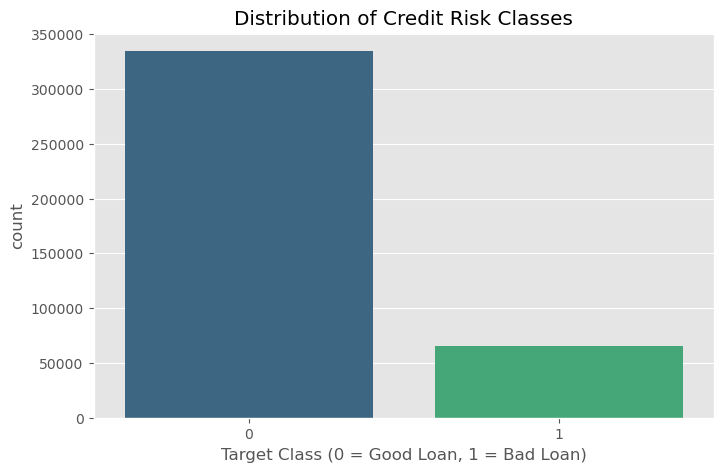

In [151]:
# Setup your local folder system
# ________________________________________________________

report_dir = Path("reports")

figure_dir = report_dir / "figures"

figure_dir.mkdir(parents=True, exist_ok=True)

# Plot the visualisation

plt.figure(figsize=(8,5))

sns.countplot(x="target",

              hue="target"
              
              ,data=X_train_eda
              
              ,palette="viridis"
              
              ,legend=False)

plt.title("Distribution of Credit Risk Classes")

plt.xlabel("Target Class (0 = Good Loan, 1 = Bad Loan)")

# Save fig 

plt.savefig(figure_dir / "target_distribution.png",dpi=300,bbox_inches="tight")

plt.show()

In [152]:
# Loan Grade Vs Default
# ________________________________________________________

grade_default = pd.crosstab(X_train_eda["grade"]
                            ,df["target"]
                            ,normalize="index")

grade_default

target,0,1
grade,,
A,0.952901,0.047099
B,0.893222,0.106778
C,0.820050,0.179950
D,0.744609,0.255391
E,0.666611,0.333389
F,0.572404,0.427596
G,0.535314,0.464686


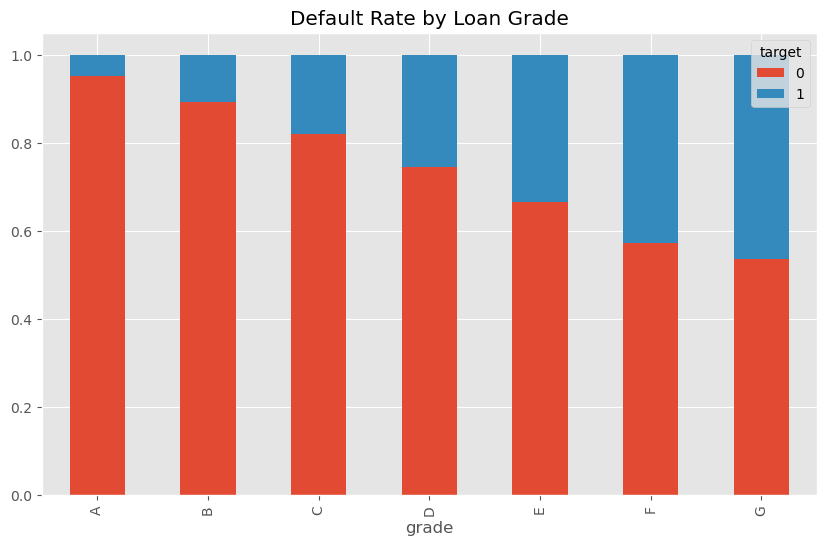

In [153]:
# Plot Loan Grade vs Default
# ________________________________________________________

grade_default.plot(

    kind="bar",

    stacked=True,

    figsize=(10,6))

plt.title("Default Rate by Loan Grade")

plt.savefig("reports/figures/default_by_grade.png",dpi=300,bbox_inches="tight")

plt.show()

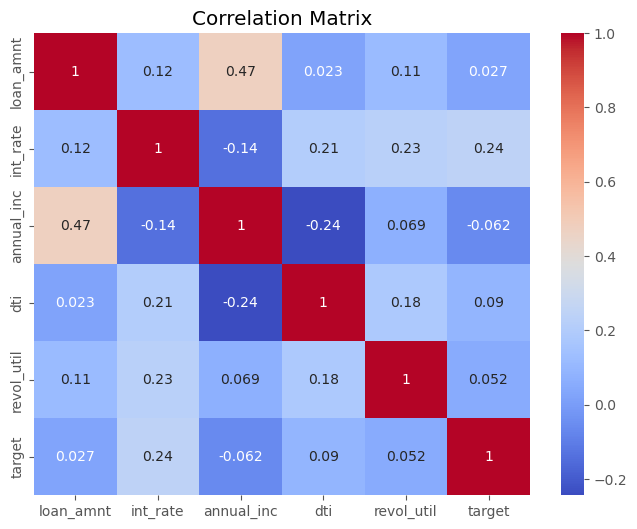

In [154]:
# Correlation Matrix
# ________________________________________________________

corr = X_train_eda[[

        "loan_amnt",

        "int_rate",

        "annual_inc",

        "dti",

        "revol_util",

        "target"]].corr()


# Plot Correlation Matrix

plt.figure(figsize=(8,6))

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm")

plt.title("Correlation Matrix")

plt.savefig("reports/figures/correlation_matrix.png"
            
            ,dpi=300
            
            ,bbox_inches="tight")

plt.show()

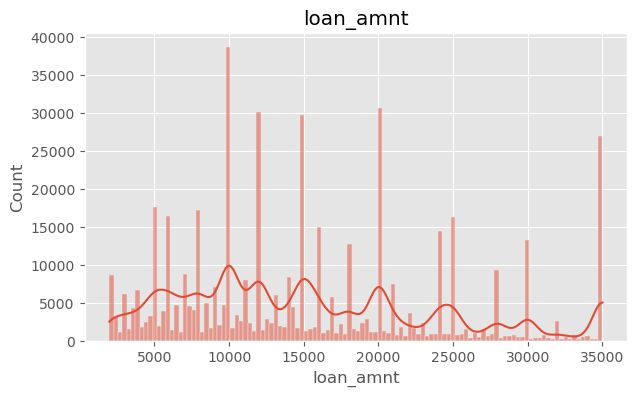

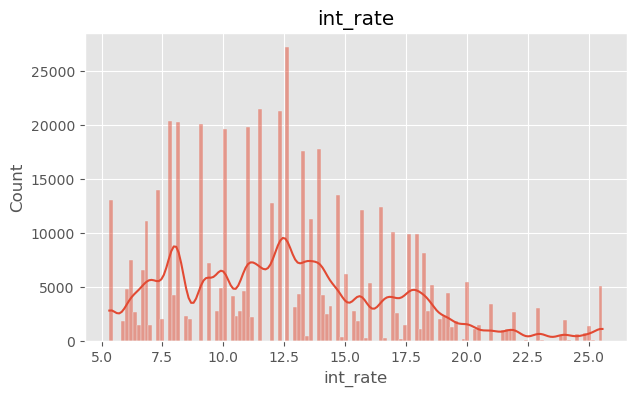

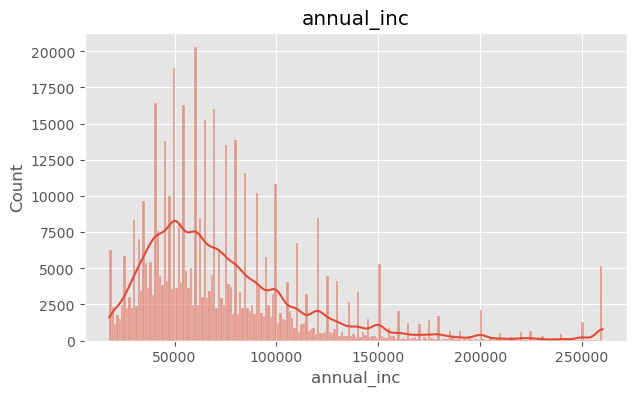

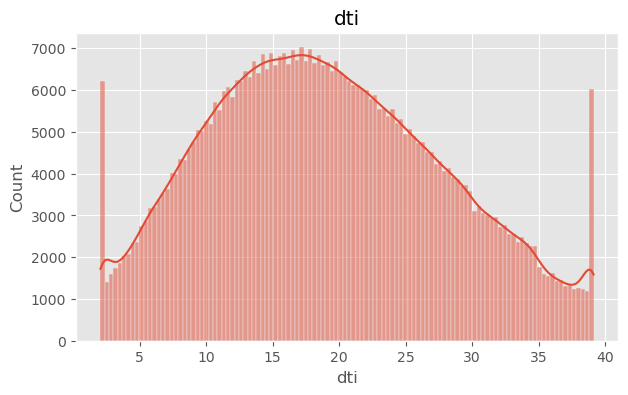

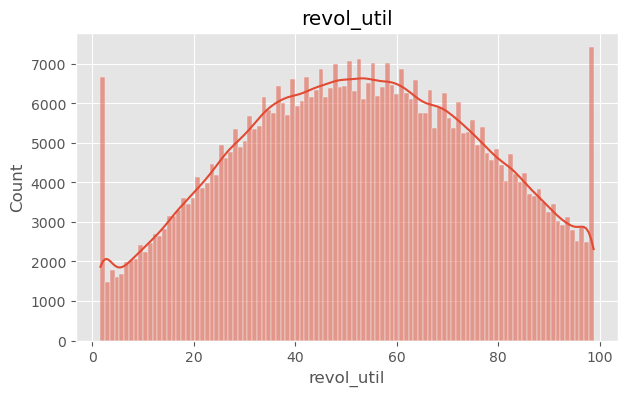

In [155]:
# Distribution of Numerical Variables
# ________________________________________________________

num_cols = ["loan_amnt"
            
            ,"int_rate"
            
            ,"annual_inc"
            
            ,"dti"
            
            ,"revol_util"]

# Plot Distribution

for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(

        df[col],

        kde=True)

    plt.title(col)

    plt.savefig(f"reports/figures/{col}_distribution.png",dpi=300,bbox_inches="tight")

    plt.show()

### Business Analysis

In [188]:
# folder for Business report

BUSINESS_DIR = REPORT_DIR / "business_analysis"

BUSINESS_DIR.mkdir(exist_ok=True)

# Reusable function

def business_risk_profile(X_train_eda, feature):

# Crosstab

    profile = pd.crosstab(

        X_train_eda[feature],

        X_train_eda["target"],

        normalize="index")

    profile.columns = [

        "Good Loan",

        "Bad Loan"]

    profile["Default Rate"] = profile["Bad Loan"]

# Save table

    profile.to_csv(BUSINESS_DIR /f"{feature}_risk_profile.csv")

# Loan Performance Bar Chart

    plt.figure(figsize=(9,5))

    profile[["Good Loan","Bad Loan"]].plot(kind="bar",stacked=True)

    plt.title(f"Loan Performance by {feature}")

    plt.ylabel("Percentage")

    plt.xlabel(feature)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(BUSINESS_DIR /f"{feature}_stacked_bar.png",dpi=300)

    plt.close()

# Default Rate Plot

    plt.figure(figsize=(9,5))

    profile["Default Rate"].sort_values(
        
        ascending=False).plot(kind="bar")

    plt.title(f"Default Rate by {feature}")

    plt.ylabel("Default Rate")

    plt.xlabel(feature)

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.savefig(BUSINESS_DIR /f"{feature}_default_rate.png",dpi=300)

    plt.close()

    return profile

In [189]:
business_features = [

    "grade",

    "purpose",

    "home_ownership",

    "term"]

risk_reports = {}

for feature in business_features:

    print("="*60)

    print(f"Business Risk Profile : {feature}")

    print("="*60)

    risk_reports[feature] = business_risk_profile(

        X_train_eda,

        feature)
    display(risk_reports[feature])

Business Risk Profile : grade


,Good Loan,Bad Loan,Default Rate
grade,,,
A,0.952901,0.047099,0.047099
B,0.893222,0.106778,0.106778
C,0.820050,0.179950,0.179950
D,0.744609,0.255391,0.255391
E,0.666611,0.333389,0.333389
F,0.572404,0.427596,0.427596
G,0.535314,0.464686,0.464686


Business Risk Profile : purpose


,Good Loan,Bad Loan,Default Rate
purpose,,,
car,0.873666,0.126334,0.126334
credit_card,0.865116,0.134884,0.134884
debt_consolidation,0.822426,0.177574,0.177574
educational,1.000000,0.000000,0.000000
home_improvement,0.856774,0.143226,0.143226
house,0.845567,0.154433,0.154433
major_purchase,0.848570,0.151430,0.151430
medical,0.832059,0.167941,0.167941
moving,0.804199,0.195801,0.195801


Business Risk Profile : home_ownership


...

,Good Loan,Bad Loan,Default Rate
term,,,
36 months,0.866752,0.133248,0.133248
60 months,0.772842,0.227158,0.227158


<Figure size 900x500 with 0 Axes>

<Figure size 900x500 with 0 Axes>

<Figure size 900x500 with 0 Axes>

<Figure size 900x500 with 0 Axes>

### Business Risk Profiling For Numerical Variables

##### Analysing numerical variables
##### by grouping them into business-friendly bands.

In [192]:
# Creating folders
# ________________________________________________________

NUMERIC_DIR = REPORT_DIR / "numerical_buss_analysis"

NUMERIC_DIR.mkdir(exist_ok=True)

In [193]:
# Resusable Function
# ________________________________________________________

def numerical_risk_profile(
    df,
    column,
    bins,
    labels=None):
   

    profile_df = df.copy()

    profile_df[f"{column}_band"] = pd.cut(

        profile_df[column],

        bins=bins,

        labels=labels,

        include_lowest=True)

    summary = (

        profile_df

        .groupby(f"{column}_band", observed=False)

        .agg(

            Loans=("target","count"),

            Defaults=("target","sum"),

            Default_Rate=("target","mean"),

            Average_Value=(column,"mean"))

        .reset_index())

    summary["Default_Rate"] *= 100

    summary.to_csv(NUMERIC_DIR /f"{column}_risk_profile.csv",index=False)

    
    # Portfolio Distribution

    plt.figure(figsize=(10,5))

    plt.bar(

        summary[f"{column}_band"].astype(str),

        summary["Loans"])plt.title(f"Loan Distribution by {column}")

    plt.ylabel("Number of Loans")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(NUMERIC_DIR /f"{column}_distribution.png",dpi=300)

    plt.close()


    # Default Rate

    plt.figure(figsize=(10,5))

    plt.bar(

        summary[f"{column}_band"].astype(str),

        summary["Default_Rate"])

    plt.title(f"Default Rate by {column}")

    plt.ylabel("Default Rate (%)")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(NUMERIC_DIR /f"{column}_default_rate.png",dpi=300)

    plt.close()

    return summary

In [199]:
# Business Risk Profile
# ________________________________________________________

numerical_configs = {

    "loan_amnt": [0,5000,10000,15000,20000,30000,40000,50000],

    "annual_inc": [0,25000,50000,75000,100000,150000,250000,1000000],

    "dti": [0,10,20,30,40,50,100],

    "int_rate": [0,5,10,15,20,25,30,40],

    "revol_util": [0,20,40,60,80,100,150]}

numerical_reports = {}

for feature, bins in numerical_configs.items():

    print("=" * 70)
    print(f"Business Risk Profile: {feature}")
    print("=" * 70)

    numerical_reports[feature] = numerical_risk_profile(
        X_train_eda,
        feature,
        bins)

    display(numerical_reports[feature])

Business Risk Profile: loan_amnt


,loan_amnt_band,Loans,Defaults,Default_Rate,Average_Value
0,"(-0.001, 5000.0]",44903,6002,13.366590,3782.527893
1,"(5000.0, 10000.0]",99430,14401,14.483556,8184.869003
2,"(10000.0, 15000.0]",88129,15507,17.595797,13053.089789
3,"(15000.0, 20000.0]",67850,12418,18.302137,18203.058585
4,"(20000.0, 30000.0]",71979,12415,17.248086,25262.127496
5,"(30000.0, 40000.0]",27709,4701,16.965607,34394.241943
6,"(40000.0, 50000.0]",0,0,NaN,NaN


Business Risk Profile: annual_inc


,annual_inc_band,Loans,Defaults,Default_Rate,Average_Value
0,"(-0.001, 25000.0]",15311,2923,19.090850,21333.567463
1,"(25000.0, 50000.0]",112089,21217,18.928708,40312.981081
2,"(50000.0, 75000.0]",121400,20602,16.970346,62990.161262
3,"(75000.0, 100000.0]",74165,11111,14.981460,87882.271328
4,"(100000.0, 150000.0]",54637,7129,13.047935,122008.220810
5,"(150000.0, 250000.0]",18114,2020,11.151595,188172.665830
6,"(250000.0, 1000000.0]",4284,442,10.317460,259809.507509


Business Risk Profile: dti


,dti_band,Loans,Defaults,Default_Rate,Average_Value
0,"(-0.001, 10.0]",66230,7959,12.017213,6.596143
1,"(10.0, 20.0]",158746,23210,14.620841,15.169620
2,"(20.0, 30.0]",124038,22780,18.365340,24.515188
3,"(30.0, 40.0]",50986,11495,22.545405,34.101705
4,"(40.0, 50.0]",0,0,NaN,NaN
5,"(50.0, 100.0]",0,0,NaN,NaN


Business Risk Profile: int_rate


,int_rate_band,Loans,Defaults,Default_Rate,Average_Value
0,"(-0.001, 5.0]",0,0,NaN,NaN
1,"(5.0, 10.0]",135658,9338,6.883486,7.940103
2,"(10.0, 15.0]",158854,26091,16.424516,12.624578
3,"(15.0, 20.0]",85652,23099,26.968430,17.341476
4,"(20.0, 25.0]",15828,5411,34.186252,22.330424
5,"(25.0, 30.0]",4008,1505,37.549900,25.568683
6,"(30.0, 40.0]",0,0,NaN,NaN


Business Risk Profile: revol_util


,revol_util_band,Loans,Defaults,Default_Rate,Average_Value
0,"(-0.001, 20.0]",43238,5318,12.299366,11.299852
1,"(20.0, 40.0]",88629,12926,14.584391,30.907842
2,"(40.0, 60.0]",111629,18730,16.778794,50.160982
3,"(60.0, 80.0]",96687,17523,18.123429,69.517759
4,"(80.0, 100.0]",59817,10947,18.300817,89.094732
5,"(100.0, 150.0]",0,0,NaN,NaN


In [205]:
# Top 10 Correlation
# ________________________________________________________

target_corr = (
    corr_matrix["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False))

top10_corr = target_corr.head(10)

print(top10_corr)

int_rate      0.244169
dti           0.089894
annual_inc    0.062721
revol_util    0.051979
loan_amnt     0.026784
Name: target, dtype: float64


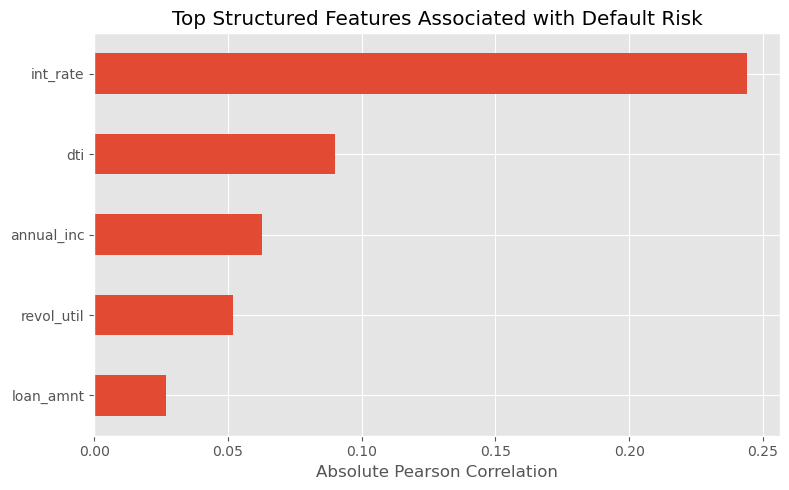

In [206]:
# Plot Top 10 Pearson Correlation 
# ________________________________________________________

plt.figure(figsize=(8,5))

top10_corr.sort_values().plot(kind="barh")

plt.xlabel("Absolute Pearson Correlation")

plt.title("Top Structured Features Associated with Default Risk")

plt.tight_layout()

plt.show()

In [164]:
# Varience Inflation Factor (VIF)
# ________________________________________________________

vif_data = X_train_eda[numerical_features]

vif_report = pd.DataFrame({
    "Feature": numerical_features,
    "VIF": [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(numerical_features))]})

print(vif_report)

      Feature       VIF
0   loan_amnt  5.593307
1    int_rate  7.422258
2  annual_inc  4.651545
3         dti  5.287225
4  revol_util  5.849891


### Executive Summary Report
##### This report will provide a concise overview of the training 
##### portfolio, data quality and Key statistical findings.

In [210]:
# Calculate summary statistics

total_records = len(X_train_eda)

default_rate = round(
    X_train_eda["target"].mean() * 100,2)

average_loan = round(
    X_train_eda["loan_amnt"].mean(),2)

average_income = round(
    X_train_eda["annual_inc"].mean(),2)

average_interest = round(
    X_train_eda["int_rate"].mean(),2)

highest_corr_feature = top10_corr.index[0]

highest_corr_value = round(
    top10_corr.iloc[0],3)

highest_vif_feature = vif_report.loc[
    vif_report["VIF"].idxmax(),"Feature"]

highest_vif = round(
    vif_report["VIF"].max(),2)

most_common_grade = (
    X_train_eda["grade"].mode()[0])

most_common_purpose = (
    X_train_eda["purpose"].mode()[0])


# Create summary

summary = f"""

EXECUTIVE SUMMARY
Explainable AI Credit Risk Decision Platform

Training Dataset Size:
{total_records:,} loans

Overall Default Rate:
{default_rate:.2f} %

Average Loan Amount:
£{average_loan:,.2f}

Average Annual Income:
£{average_income:,.2f}

Average Interest Rate:
{average_interest:.2f} %

Most Common Loan Grade:
{most_common_grade}

Most Common Loan Purpose:
{most_common_purpose}

Highest Correlated Feature:
{highest_corr_feature}

Correlation Coefficient:
{highest_corr_value}

Highest VIF Feature:
{highest_vif_feature}

Highest VIF:
{highest_vif}

END OF REPORT

"""

# Save report

with open(REPORT_DIR / "executive_summary.txt","w",
          
          encoding="utf-8") as file:
    
    file.write(summary)

print(summary)



EXECUTIVE SUMMARY
Explainable AI Credit Risk Decision Platform

Training Dataset Size:
400,000 loans

Overall Default Rate:
16.36 %

Average Loan Amount:
£15,351.19

Average Annual Income:
£75,494.55

Average Interest Rate:
12.56 %

Most Common Loan Grade:
C

Most Common Loan Purpose:
debt_consolidation

Highest Correlated Feature:
int_rate

Correlation Coefficient:
0.244

Highest VIF Feature:
int_rate

Highest VIF:
7.42

END OF REPORT




### Feature Recommendation Report

##### Purpose:

##### Produces a feature assessment report using:

##### • Missing percentage
##### • Pearson correlation
##### • Variance Inflation Factor

##### Recommendation:

##### Keep
##### Review
##### Remove

In [241]:
# Buiding Report
# ________________________________________________________

# Missing percentage

missing_pct = (X_train_eda.isnull().mean()*100)

feature_report = pd.DataFrame({"Feature":
        
                               X_train_eda.columns})

feature_report["Missing %"] = (feature_report["Feature"]

    .map(missing_pct))

# Pearson correlation

corr_lookup = target_corr.to_dict()

feature_report["Absolute Correlation"] = (

    feature_report["Feature"]

    .map(corr_lookup))

# VIF lookup

vif_lookup = dict(

    zip(vif_report["Feature"],

        vif_report["VIF"]))

feature_report["VIF"] = (feature_report["Feature"].map(vif_lookup))

In [242]:
# feature recommendation
# ________________________________________________________

def recommend(row):

# Target column

    if row["Feature"] == "target":

        return "Target"

# High missing

    if row["Missing %"] > 40:

        return "Remove"

# High multicollinearity

    if pd.notnull(row["VIF"]):

        if row["VIF"] > 5:

            return "Review"

# Very weak predictor

    if pd.notnull(row["Absolute Correlation"]):

        if row["Absolute Correlation"] < 0.03:

            return "Review"

    return "Keep"


feature_report["Recommendation"] = (feature_report

    .apply(recommend,axis=1))

In [243]:
# feature reason
# ________________________________________________________

def reason(row):

    if row["Recommendation"] == "Remove":

        return "More than 40% missing values"

    if row["Recommendation"] == "Review":

        if pd.notnull(row["VIF"]) and row["VIF"] > 5:

            return "High multicollinearity"

        return "Weak relationship with target"

    if row["Recommendation"] == "Keep":

        return "Suitable for modelling"

    return "Target variable"


feature_report["Reason"] = (feature_report

    .apply(reason,axis=1))

In [244]:
# Feature recommendation report
# ________________________________________________________

feature_report = feature_report.sort_values(

    by=["Recommendation","Missing %"],

    ascending=[True,False])

feature_report.to_csv(REPORT_DIR /"feature_recommendations.csv",index=False)

display(feature_report.tail(20))

,Feature,Missing %,Absolute Correlation,VIF,Recommendation,Reason
79,addr_state,0.00025,NaN,NaN,Keep,Suitable for modelling
80,debt_settlement_flag,0.00025,NaN,NaN,Keep,Suitable for modelling
81,zip_code,0.00025,NaN,NaN,Keep,Suitable for modelling
82,tax_liens,0.00025,NaN,NaN,Keep,Suitable for modelling
83,purpose,0.00025,NaN,NaN,Keep,Suitable for modelling
84,url,0.00025,NaN,NaN,Keep,Suitable for modelling
85,grade,0.00025,NaN,NaN,Keep,Suitable for modelling
86,pymnt_plan,0.00025,NaN,NaN,Keep,Suitable for modelling
87,issue_d,0.00025,NaN,NaN,Keep,Suitable for modelling
88,verification_status,0.00025,NaN,NaN,Keep,Suitable for modelling
